### importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.models import Sequential
from keras.layers import Dense
from xgboost import XGBClassifier
import os
import warnings
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.Max_columns',None) # to see all the columns of the dataset

In [2]:
# importing train and test data
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

In [3]:
# getting info about the training data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### feature engineering and feature selection

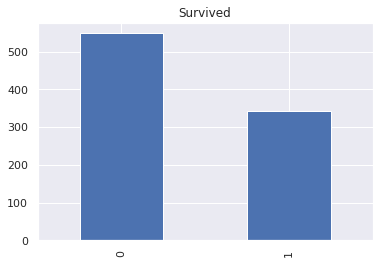

In [4]:
# checking wether dataset is balanced or not
train['Died'] = 1-train['Survived']
train.Survived.value_counts().plot(kind='bar')
plt.title('Survived')
plt.show()

for Ticket feature I have taked first letter of each data and the graph suggests tha it has something to do with survival

In [5]:
train.Ticket = train.Ticket.str[0]
test.Ticket = train.Ticket.str[0]

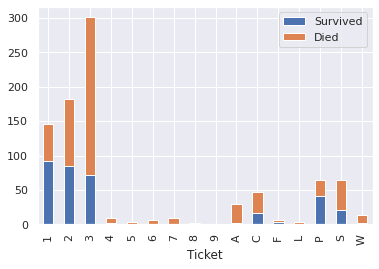

In [6]:
train.groupby('Ticket')['Survived','Died'].sum().plot(kind='bar',stacked = True)
plt.show()

In [7]:
ticket_map = {
    '1':'1','2':'2','3':'3','4':'4','5':'4','6':'4','7':'4','8':'4','9':'4','P':'P','S':'S','C':'C','A':'A','W':'W','F':'F','L':'L'
            }
train.Ticket = train.Ticket.map(ticket_map)
test.Ticket = test.Ticket.map(ticket_map)

In [8]:
train.Ticket.value_counts(),test.Ticket.value_counts()

(3    301
 2    183
 1    146
 P     65
 S     65
 C     47
 4     31
 A     29
 W     13
 F      7
 L      4
 Name: Ticket, dtype: int64,
 3    145
 2     83
 1     60
 P     36
 S     31
 C     24
 A     15
 4     12
 W      6
 F      3
 L      3
 Name: Ticket, dtype: int64)

Age feature has some outlier but important thing is that the it looks like they might had a policy of ladies first so I have filled the null Age data according to their Sex

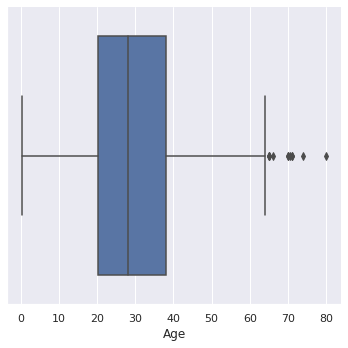

(29.69911764705882, 28.0)

In [9]:
sns.catplot(x='Age',data = train,kind= 'box')
plt.show()
train.Age.mean(),train.Age.median()

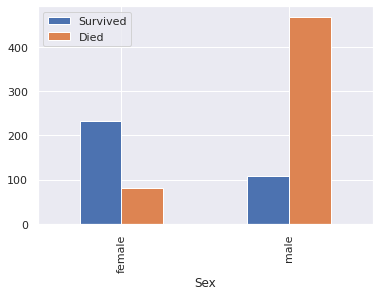

In [10]:
train.groupby('Sex')['Survived','Died'].sum().plot.bar()
plt.show()

In [11]:
train['Age'][(train.Sex == 'male') & (train.Age.isnull())] = train.Age.median()
train['Age'][(train.Sex == 'female') & (train.Age.isnull())] = train.Age.median()
test['Age'][(test.Sex == 'male') & (test.Age.isnull())] = test.Age.median()
test['Age'][(test.Sex == 'female') & (test.Age.isnull())] = test.Age.median()

In Embarked columns it has only two NaN values which can be filled by most frequent value

In [12]:
train.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [13]:
# filling null value with most frequent class
train.Embarked.fillna('S',inplace=True)

Extracting the title from the Name column

In [14]:
train['Name_Title'] = train.Name.str.split(',',expand=True)[1].str.split('.',expand=True)[0].str.strip()
test['Name_Title'] = test.Name.str.split(',',expand=True)[1].str.split('.',expand=True)[0].str.strip()

In [15]:
Title_map = {
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Jonkheer": "Other",
    "Don": "Other",
    "Sir" : "Other",
    "Dr": "Officer",
    "Rev": "Officer",
    "the Countess":"Other",
    "Mme": "Mrs",
    "Mlle": "Miss",
    "Ms": "Mrs",
    "Mr" : "Mr",
    "Mrs" : "Mrs",
    "Miss" : "Miss",
    "Master" : "Master",
    "Lady" : "Other",
    'Dona' : "Other"
}
train.Name_Title = train.Name_Title.map(Title_map)
test.Name_Title = test.Name_Title.map(Title_map)

In [16]:
# Deleting the Name and PassengerID
del train['Name']
del test['Name']
del train['PassengerId']
del test['PassengerId']

handling the null values in Cabin column according to their Ticket class

In [17]:
train.Ticket[train.Cabin.isnull()].value_counts()

3    279
2    168
S     61
C     45
1     35
A     29
4     29
P     21
W     10
F      6
L      4
Name: Ticket, dtype: int64

In [18]:
# taking only first letter of cabin column's data 
test['Cabin'] = test['Cabin'].str[0]
train['Cabin'] = train['Cabin'].str[0]

In [19]:
train[['Cabin','Ticket']].groupby('Cabin',dropna = False).describe(include = 'all')

Ticket                
       count unique top freq
Cabin                       
A         15      4   1   10
B         47      6   1   27
C         59      3   1   41
D         33      5   1   15
E         32      7   1   17
F         13      3   2    7
G          4      2   P    2
T          1      1   1    1
NaN      687     11   3  279

In [20]:
# This function which will replace the null value in cabin with the similar value as of other data according to their Ticket 
def cabin(data):
    df= data.copy()
    for i in range(len(df.Cabin)):
        if pd.isna(df['Cabin'][i]):
            
            cabin = train['Cabin'][train.Ticket == train['Ticket'][i]].mode()
            if len(cabin) == 0:
                cabin = 'M' # If there is no match then replace it with 'M' for missing class
            else:
                cabin = cabin[0]
            df['Cabin'][i] = cabin
    return df['Cabin']

In [21]:
train['Cabin'] = cabin(train)
test['Cabin'] = cabin(test)

In [22]:
print(train.Cabin.value_counts())
print(test.Cabin.value_counts())

D    373
F    226
C    115
B     92
M     33
E     32
A     15
G      4
T      1
Name: Cabin, dtype: int64
D    144
C    112
F     94
B     35
M     16
E      9
A      7
G      1
Name: Cabin, dtype: int64


In [23]:
cabin_map = {'M':'M','C':'C','B':'B','D':'D','E':'E','A':'A','F':'F','G':'G','T':'G'}
train.Cabin = train.Cabin.map(cabin_map)
test.Cabin = test.Cabin.map(cabin_map)
train.Cabin = train.Cabin.astype('O')
test.Cabin = test.Cabin.astype('O')

In [24]:
test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin         0
Embarked      0
Name_Title    0
dtype: int64

Fare column in test data has one missing value. I have filled it with the median value acoording to the its cabin class

In [25]:
test[['Cabin','Fare']].groupby('Cabin',dropna = False).describe(include = 'all')

Fare                                                                  \
       count       mean         std      min       25%       50%         75%   
Cabin                                                                          
A        7.0  44.716657   25.399971  27.7208  29.70000  30.50000   56.768750   
B       35.0  82.768574  113.461955   0.0000   8.05000  36.75000   87.883350   
C      112.0  51.041333   68.380044   6.9500   8.01875  20.94585   58.162500   
D      144.0  19.601390   19.457322   0.0000   7.84270  13.00000   25.806275   
E        9.0  84.921756   40.892995  26.0000  55.44170  83.15830  134.500000   
F       94.0  22.222073   29.556979   3.1708   7.88335  13.00000   26.000000   
G        1.0  16.700000         NaN  16.7000  16.70000  16.70000   16.700000   
M       15.0  15.834720   16.843473   7.7500   7.76250   9.32500   15.139550   

                 
            max  
Cabin            
A       81.8583  
B      512.3292  
C      263.0000  
D      151.5500  
E      134.5000  
F      211.3375  
G       16.7000  
M       73.5000

In [26]:
test.Fare.fillna(test['Fare'][test.Cabin==test.Cabin[test.Fare.isnull()].values[0]].median(),inplace = True)

In [27]:
print('TRAIN_DATA')
print('Pclass',len(train.Pclass.value_counts()))
print('Sex',len(train.Sex.value_counts()))
print('SibSp',len(train.SibSp.value_counts()))
print('Parch',len(train.Parch.value_counts()))
print('Cabin',len(train.Cabin.value_counts()))
print('Embarked',len(train.Embarked.value_counts()))
print('Name_label',len(train.Name_Title.value_counts()))
print('TEST_DATA')
print('Pclass',len(test.Pclass.value_counts()))
print('Sex',len(test.Sex.value_counts()))
print('SibSp',len(test.SibSp.value_counts()))
print('Parch',len(test.Parch.value_counts()))
print('Cabin',len(test.Cabin.value_counts()))
print('Embarked',len(test.Embarked.value_counts()))
print('Name_label',len(test.Name_Title.value_counts()))

TRAIN_DATA
Pclass 3
Sex 2
SibSp 7
Parch 7
Cabin 8
Embarked 3
Name_label 6
TEST_DATA
Pclass 3
Sex 2
SibSp 7
Parch 8
Cabin 8
Embarked 3
Name_label 6


I hace combined the all the number of family members and based on it I have classified into solo travel,family travel and group travel

In [28]:
train['Family'] = train.Parch + train.SibSp + 1
test['Family'] = test.Parch + test.SibSp + 1

In [29]:
train['Solo_Travel'] = np.where(train.Family ==1,1,0)
train['Family_Travel'] = np.where((train.Family>1)&(train.Family<=4),1,0)
train['Group_Travel'] = np.where(train.Family>4,1,0)
test['Solo_Travel'] = np.where(test.Family ==1,1,0)
test['Family_Travel'] = np.where((test.Family>1)&(test.Family<=4),1,0)
test['Group_Travel'] = np.where(test.Family>4,1,0)

In [30]:
del train['Parch']
del train['SibSp']
del test['Parch']
del test['SibSp']

Pclass v/s Survived plot suggests that class 1 and 2 might be of the vips

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64


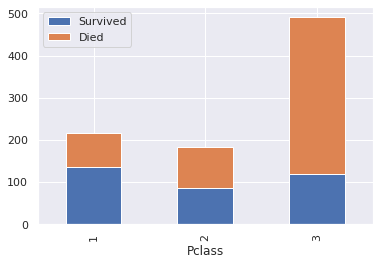

In [31]:
print(train.groupby('Pclass')['Survived'].value_counts())
train.groupby('Pclass')['Survived','Died'].sum().plot.bar(stacked = True)
plt.show()

In [32]:
train.head()

,Survived,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Died,Name_Title,Family,Solo_Travel,Family_Travel,Group_Travel
0,0,3,male,22.0,A,7.2500,M,S,1,Mr,2,0,1,0
1,1,1,female,38.0,P,71.2833,C,C,0,Mrs,2,0,1,0
2,1,3,female,26.0,S,7.9250,D,S,0,Miss,1,1,0,0
3,1,1,female,35.0,1,53.1000,C,S,0,Mrs,2,0,1,0
4,0,3,male,35.0,3,8.0500,D,S,1,Mr,1,1,0,0


In [33]:
# ecoding the categorical variable
train_final = pd.get_dummies(train,drop_first = True)
test_final = pd.get_dummies(test,drop_first = True)

In [34]:
train_final.shape,test_final.shape

((891, 34), (418, 32))

adding a new column which suggest if the passenger was child or senior citizon or not

In [35]:
train_final['child'] = np.where(train_final['Age']<18,1,0)
test_final['child'] = np.where(test_final['Age']<18,1,0)
train_final['senior_citizen'] = np.where(train_final['Age']>60,1,0)
test_final['senior_citizen'] = np.where(test_final['Age']>60,1,0)

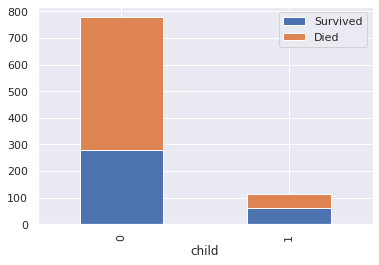

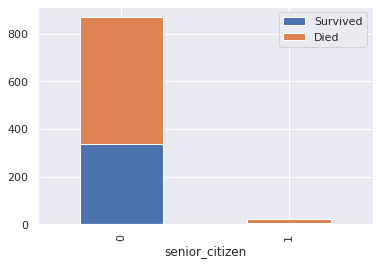

In [36]:
train_final.groupby('child')['Survived','Died'].sum().plot.bar(stacked = True)
train_final.groupby('senior_citizen')['Survived','Died'].sum().plot.bar(stacked = True)
plt.show()

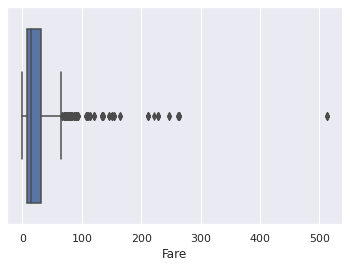

In [37]:
sns.boxplot(train.Fare)
plt.show()

In [38]:
# to remove the outlier in Fare column, I have replaced all those with 100
train_final.Fare[train_final['Fare']>100] = 100
test_final.Fare[test_final['Fare']>100] = 100

In [39]:
del train_final['Died']

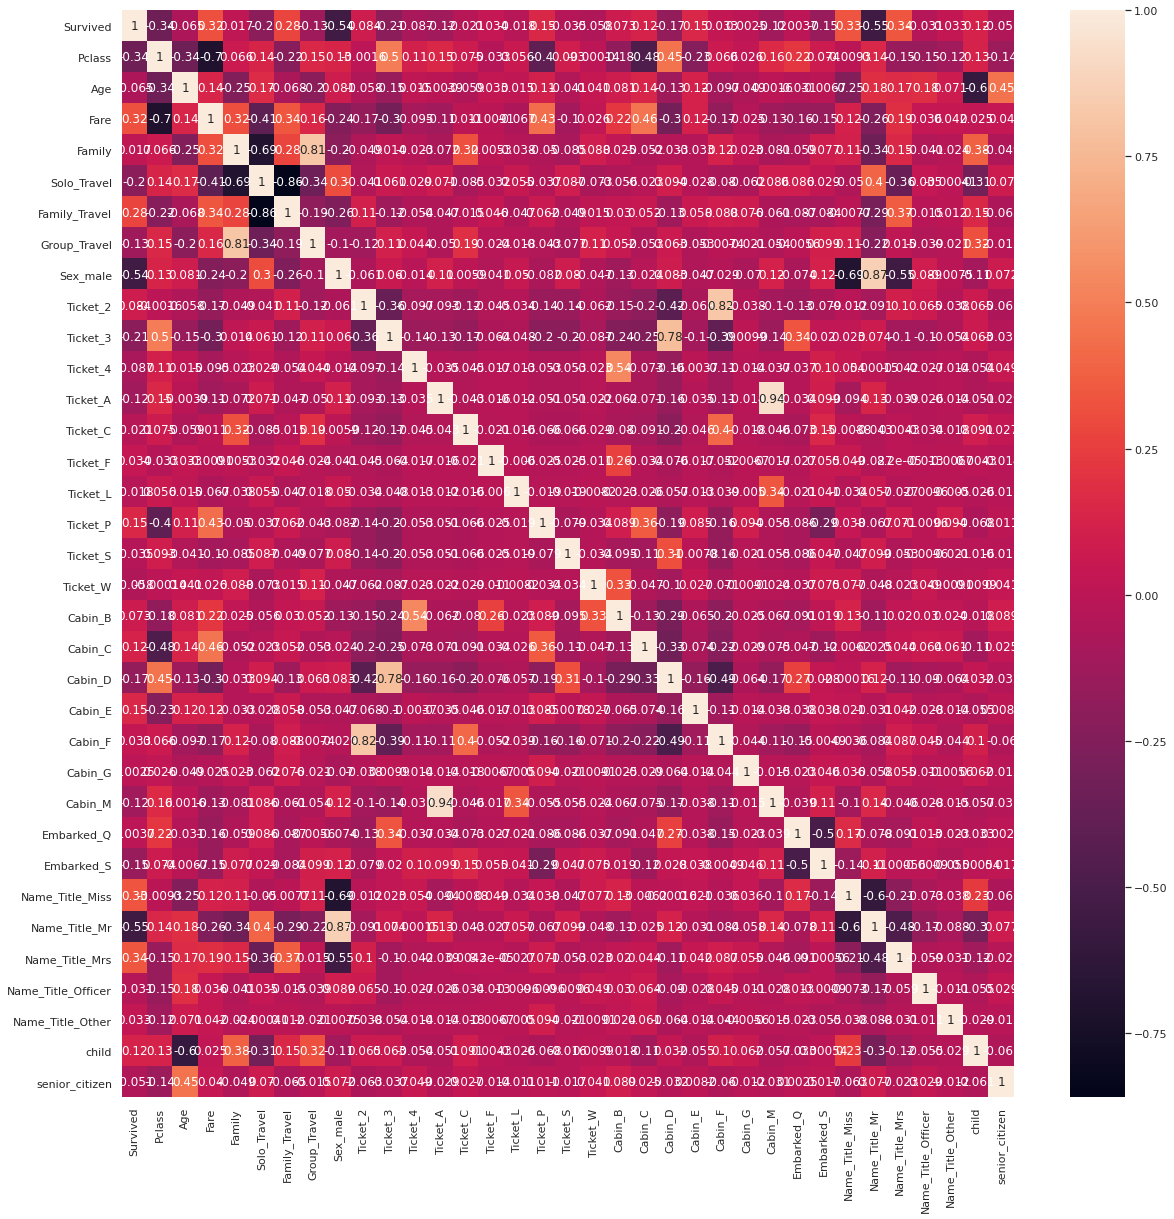

In [40]:
# printing the correlation matrix
cor = train_final.corr()
plt.subplots(figsize=(20,20))
sns.heatmap(cor,annot=True)
plt.show()

In [41]:
def correlation(corr_matrix,threshold):
    col = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                col_name = corr_matrix.columns[i]
                col.add(col_name)
    return list(col)

In [42]:
print('columns with positive or negative correlation of more than 0.9 -> ',len(correlation(cor,0.9)))

columns with positive or negative correlation of more than 0.9 ->  1


In [43]:
correlation(cor,0.9)

['Cabin_M']

In [44]:
# Removing the feature with high correlation
train_final = train_final.drop(correlation(cor,0.9),axis = 1)
test_final = test_final.drop(correlation(cor,0.9),axis = 1)

In [45]:
# making the train test split
ip_train = train_final.drop('Survived',axis = 1)
op_train = train_final['Survived']
x_train,x_test,y_train,y_test = train_test_split(ip_train,op_train,random_state = 0,test_size = 0.4)

### LogisticRegression

In [46]:
LR_alg = LogisticRegression()
LR_alg.fit(x_train,y_train)
logistic_regression_accuracy = LR_alg.score(x_test,y_test)
# printing the perfomance of classifier
print(logistic_regression_accuracy)
y_pred_lr = LR_alg.predict(x_test)
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

0.8207282913165266
[[191  30]
 [ 34 102]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       221
           1       0.77      0.75      0.76       136

    accuracy                           0.82       357
   macro avg       0.81      0.81      0.81       357
weighted avg       0.82      0.82      0.82       357



### RandomForestClassifier

In [47]:
RF_alg = RandomForestClassifier(
                                n_estimators = 100,
                                random_state = 9
                                )
RF_alg.fit(x_train,y_train)
random_forest_accuracy = RF_alg.score(x_test,y_test)
# printing the perfomance of classifier
print(random_forest_accuracy)
y_pred_rf = RF_alg.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

0.8095238095238095
[[189  32]
 [ 36 100]]
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       221
           1       0.76      0.74      0.75       136

    accuracy                           0.81       357
   macro avg       0.80      0.80      0.80       357
weighted avg       0.81      0.81      0.81       357



### Hypertuning the parameters of RandomForestClassifier

In [48]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 250, num = 5)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt','log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(2, 10, num = 5)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [int(x) for x in np.linspace(2,20,5)]
# Minimum number of samples required at each leaf node
min_samples_leaf = [int(x) for x in np.linspace(2,10,5)]
# Method of selecting samples for training each tree
bootstrap = [True]
criterion = ['gini','entropy']

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap,
               'criterion': criterion}

rf = RandomForestClassifier()
rf_random_search = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 200, cv = 5, verbose=2, random_state=9, n_jobs = -1)
rf_random_search.fit(x_train,y_train)

rf_random_search.best_params_

# for fine tuning I have used GridsearchCV after RandomizedSearchCV
grid = {
    'n_estimators' : [rf_random_search.best_params_['n_estimators'],rf_random_search.best_params_['n_estimators']+50,rf_random_search.best_params_['n_estimators']+100],
    'min_samples_split' : [rf_random_search.best_params_['min_samples_split'],rf_random_search.best_params_['min_samples_split']-1,rf_random_search.best_params_['min_samples_split']+1],
    'min_samples_leaf' : [rf_random_search.best_params_['min_samples_leaf'],rf_random_search.best_params_['min_samples_leaf']-1,rf_random_search.best_params_['min_samples_leaf']+1],
    'max_depth' : [rf_random_search.best_params_['max_depth'],None],
    'max_features' : [rf_random_search.best_params_['max_features']],
    'criterion' : [rf_random_search.best_params_['criterion']],
    'bootstrap' : [rf_random_search.best_params_['bootstrap']]
}
rf_clf = RandomForestClassifier()
rf_grid_search = GridSearchCV(rf_clf,grid,n_jobs = -1,cv=5,verbose = 3)
rf_grid_search.fit(x_train,y_train)

rf_grid_search.best_params_

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 357 tasks      | elapsed:   48.7s
[Parallel(n_jobs=-1)]: Done 640 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  2.2min finished


Fitting 5 folds for each of 54 candidates, totalling 270 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 120 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 270 out of 270 | elapsed:   47.7s finished


{'bootstrap': True,
 'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 19,
 'n_estimators': 150}

#### Feature Importance

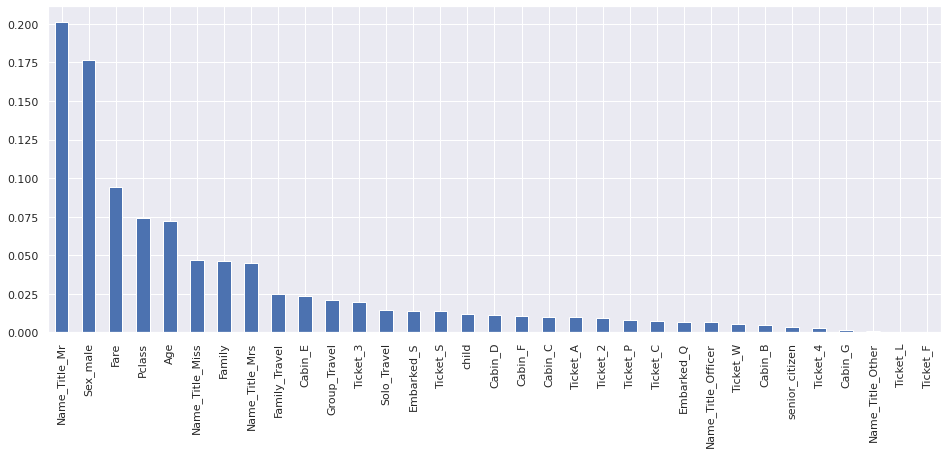

In [49]:
feat_imp = pd.Series(rf_grid_search.best_estimator_.feature_importances_,index = x_train.columns)
plt.subplots(figsize =(16,6))
feat_imp.sort_values(ascending=False).plot.bar()
plt.show()

In [50]:
# printing the perfomance of classifier
random_forest_accuracy_grid = rf_grid_search.score(x_test,y_test)
print(random_forest_accuracy_grid)
y_pred_grid = rf_grid_search.predict(x_test)
print(confusion_matrix(y_test,y_pred_grid))
print(classification_report(y_test,y_pred_grid))

0.8207282913165266
[[192  29]
 [ 35 101]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       221
           1       0.78      0.74      0.76       136

    accuracy                           0.82       357
   macro avg       0.81      0.81      0.81       357
weighted avg       0.82      0.82      0.82       357



### XGBoostClassifier 

In [51]:
classifier = XGBClassifier()
classifier.fit(x_train,y_train)
# printing the perfomance of classifier
print(classifier.score(x_test,y_test))
y_pred_clf = classifier.predict(x_test)
print(confusion_matrix(y_test,y_pred_clf))
print(classification_report(y_test,y_pred_clf))

0.8123249299719888
[[191  30]
 [ 37  99]]
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       221
           1       0.77      0.73      0.75       136

    accuracy                           0.81       357
   macro avg       0.80      0.80      0.80       357
weighted avg       0.81      0.81      0.81       357



### Hypertuning the parameters of XGBoostClassifier

In [52]:
xgb_params = {
    'objective' : ['binary:logistic'],
    'booster' : ['gbtree'],
    'eval_metric' : ['logloss'],
    'max_depth': [int(i) for i in np.linspace(2,10,5)],
    'min_child_weight':[int(i) for i in np.linspace(1,5,5)],
    'gamma' : [i for i in np.linspace(0.0,1,6)],
    'subsample' : [ i for i in np.linspace(0.6,1.0,9)],
    'colsample_bytree' : [i for i in np.linspace(0.6,1.0,9)],
    'learning_rate' : [0.01,0.05,0.1,0.15,0.2,0.25,0.3]
}
xgb_params
xgb = XGBClassifier()
xgb_hptune = RandomizedSearchCV(xgb,xgb_params,cv=5,random_state = 0,n_iter = 200,n_jobs = -1,verbose = 2)
xgb_hptune.fit(x_train,y_train)
print(xgb_hptune.best_params_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 590 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 993 out of 1000 | elapsed:   33.2s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   33.3s finished


{'subsample': 0.6, 'objective': 'binary:logistic', 'min_child_weight': 4, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.6000000000000001, 'eval_metric': 'logloss', 'colsample_bytree': 0.95, 'booster': 'gbtree'}


In [53]:
# printing the perfomance of classifier
print(xgb_hptune.score(x_test,y_test))
y_pred_xgb = xgb_hptune.predict(x_test)
print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

0.84593837535014
[[203  18]
 [ 37  99]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       221
           1       0.85      0.73      0.78       136

    accuracy                           0.85       357
   macro avg       0.85      0.82      0.83       357
weighted avg       0.85      0.85      0.84       357



### NeuralNetwork

In [54]:
# initialising the NN
model = Sequential()

# layers
model.add(Dense(16, kernel_initializer = 'uniform', activation = 'relu', input_dim = ip_train.shape[1]))
model.add(Dense(16, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# compiling the NN
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
 # filepath required for checkpoint
filepath = os.path.join('./',"titanic.best.hdf5")
# making a checkpoint
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# fitting the training data to the model
model_history = model.fit(x_train,y_train,validation_data = (x_test, y_test),epochs=200,verbose = 1, batch_size=32,callbacks=[checkpoint])

# loading the best weights to the model and compiling it again
model.load_weights(filepath)
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# printing the perfomance of classifier
y_pred_nn = model.predict(x_test)
y_pred_nn = np.where(y_pred_nn>0.5,1,0)
print(confusion_matrix(y_test,y_pred_nn))
print(classification_report(y_test,y_pred_nn))

Epoch 1/200
 1/17 [>.............................] - ETA: 0s - loss: 0.6931 - accuracy: 0.6562
Epoch 00001: val_accuracy improved from -inf to 0.61905, saving model to ./titanic.best.hdf5
17/17 [==============================] - 0s 14ms/step - loss: 0.6920 - accuracy: 0.6142 - val_loss: 0.6903 - val_accuracy: 0.6190
Epoch 2/200
 1/17 [>.............................] - ETA: 0s - loss: 0.6923 - accuracy: 0.5000
Epoch 00002: val_accuracy improved from 0.61905 to 0.65826, saving model to ./titanic.best.hdf5
17/17 [==============================] - 0s 4ms/step - loss: 0.6884 - accuracy: 0.6124 - val_loss: 0.6846 - val_accuracy: 0.6583
Epoch 3/200
 1/17 [>.............................] - ETA: 0s - loss: 0.6822 - accuracy: 0.6875
Epoch 00003: val_accuracy improved from 0.65826 to 0.66387, saving model to ./titanic.best.hdf5
17/17 [==============================] - 0s 4ms/step - loss: 0.6808 - accuracy: 0.6255 - val_loss: 0.6714 - val_accuracy: 0.6639
Epoch 4/200
 1/17 [>......................

In [55]:
model.load_weights(filepath)

### Final Prediction

I have taken the mean of all the models that has been built for final prediction

In [56]:
# getting the final test prediction from all the models
y_pred_xgb = xgb_hptune.predict(test_final) # XGBClassifier with hypertuning of parameters
y_pred_grid = rf_grid_search.predict(test_final) # RandomForestClassifier with hypertuning of parameters
y_pred_lr = LR_alg.predict(test_final) # LogisticRegression
y_pred_clf = classifier.predict(test_final) # XGBClassifier without hypertuning of parameters
# from neural network retriving the final prediciton
y_pred_nn = model.predict(test_final)
y_pred_nn = np.where(y_pred_nn > 0.5,1,0)
y_pred_nnn = []
for i in y_pred_nn:
    y_pred_nnn.append(i[0])
y_pred_nnn = np.array(y_pred_nnn) 
# making final prediction as mean of all the predictions
prediction = (y_pred_xgb + y_pred_grid + y_pred_nnn + y_pred_lr )/4
prediction = np.where(prediction > 0.5,1,0)

# Saving the prediciton into the CSV file
test = pd.read_csv('../input/titanic/test.csv')
titanic_submission = pd.DataFrame(test['PassengerId'])
titanic_submission['Survived'] = prediction
titanic_submission.to_csv('./titanic_dataset_prediction.csv',index=False)
